In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, precision_score, recall_score
)
import joblib

In [3]:
df = pd.read_csv('../data/preprocessed_train.csv')

print(df.shape)
df.head()

(307511, 244)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FONDKAPREMONT_MODE_reg oper spec account,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,False,False,False,False,False,False,False,True,False,False
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,...,False,False,False,False,False,False,False,False,False,False
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225.0,...,False,False,False,False,False,False,True,False,False,False
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039.0,...,False,False,False,False,False,False,True,False,False,False
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038.0,...,False,False,False,False,False,False,True,False,False,False


In [4]:
target_col = 'TARGET'
id_col = 'SK_ID_CURR'

X = df.drop(columns=[target_col])
y = df[target_col]

# Drop ID from modeling features
if id_col in X.columns:
    X = X.drop(columns=[id_col])

print(X.shape, y.shape)

(307511, 242) (307511,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(246008, 242) (61503, 242)


In [6]:
def ks_statistic(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    ks = np.max(tpr - fpr)
    return ks

def best_f1_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    
    # precision_recall_curve returns thresholds of length n-1
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_test, y_proba)
    auprc = average_precision_score(y_test, y_proba)
    
    best_thresh, best_f1 = best_f1_threshold(y_test, y_proba)
    y_pred = (y_proba >= best_thresh).astype(int)
    
    return {
        'model': name,
        'auc': auc,
        'gini': gini,
        'ks': ks,
        'auprc': auprc,
        'best_threshold': best_thresh,
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'y_proba': y_proba,
        'fitted_model': model
    }

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.1,
        max_iter=1000,  
        class_weight='balanced'
    ))
])

In [8]:
log_result = evaluate_model("Logistic Regression", log_reg, X_train, y_train, X_test, y_test)
print(log_result)

{'model': 'Logistic Regression', 'auc': 0.7534405275002061, 'gini': 0.5068810550004121, 'ks': np.float64(0.38122704201617624), 'auprc': 0.2375923747836035, 'best_threshold': np.float64(0.6851316984370556), 'f1': 0.30526315789473685, 'precision': 0.2526732673267327, 'recall': 0.38549848942598186, 'y_proba': array([0.4481186 , 0.31740632, 0.73308318, ..., 0.27167948, 0.63548188,
       0.60643579], shape=(61503,)), 'fitted_model': Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000))])}


In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_result = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

In [10]:
print(rf_result)

{'model': 'Random Forest', 'auc': 0.746368621526532, 'gini': 0.4927372430530641, 'ks': np.float64(0.3705351340311823), 'auprc': 0.22616610541100163, 'best_threshold': np.float64(0.5890211423814764), 'f1': 0.2947993625959728, 'precision': 0.23017758172152472, 'recall': 0.40986908358509566, 'y_proba': array([0.43233049, 0.39352353, 0.54497809, ..., 0.41911968, 0.58264577,
       0.57393691], shape=(61503,)), 'fitted_model': RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)}


In [11]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_result = evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test)
print(xgb_result)

c:\Users\humza\Documents\VSCODE_Projects\jarvis_data_eng_HumzaInam\credit_risk_scoring_ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:26:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'model': 'XGBoost', 'auc': 0.7678451217313511, 'gini': 0.5356902434627022, 'ks': np.float64(0.4028410590145023), 'auprc': 0.2595049514889626, 'best_threshold': np.float32(0.6680234), 'f1': 0.31788079470198677, 'precision': 0.26117372716673143, 'recall': 0.4060422960725076, 'y_proba': array([0.4668119 , 0.40339497, 0.77249455, ..., 0.37909546, 0.62937105,
       0.5569543 ], shape=(61503,), dtype=float32), 'fitted_model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, m

In [12]:
results = pd.DataFrame([
    {k: v for k, v in log_result.items() if k not in ['y_proba', 'fitted_model']},
    {k: v for k, v in rf_result.items() if k not in ['y_proba', 'fitted_model']},
    {k: v for k, v in xgb_result.items() if k not in ['y_proba', 'fitted_model']},
])

results = results[['model', 'auc', 'gini', 'ks', 'auprc', 'f1', 'best_threshold', 'precision', 'recall']]
results.sort_values('auc', ascending=False)

,model,auc,gini,ks,auprc,f1,best_threshold,precision,recall
2,XGBoost,0.767845,0.535690,0.402841,0.259505,0.317881,0.668023,0.261174,0.406042
0,Logistic Regression,0.753441,0.506881,0.381227,0.237592,0.305263,0.685132,0.252673,0.385498
1,Random Forest,0.746369,0.492737,0.370535,0.226166,0.294799,0.589021,0.230178,0.409869


##### AUROC is the main ranking metric for credit risk, while AUPRC is useful because the dataset is imbalanced. Gini and KS help translate model performance into banking-friendly language.

##### The XGBoost model achieved the highest AUROC (~0.768), outperforming logistic regression and random forest. This improvement is driven by its ability to capture non-linear relationships and feature interactions. The KS statistic (~0.40) indicates excellent separation between defaulters and non-defaulters, making it the best candidate for the final model despite reduced interpretability compared to logistic regression.

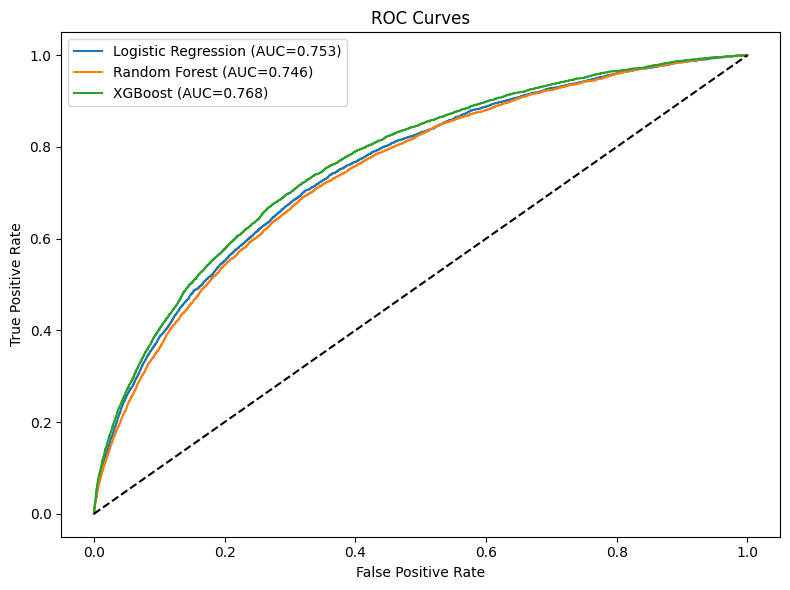

In [13]:
plt.figure(figsize=(8, 6))

for result in [log_result, rf_result, xgb_result]:
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    plt.plot(fpr, tpr, label=f"{result['model']} (AUC={result['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

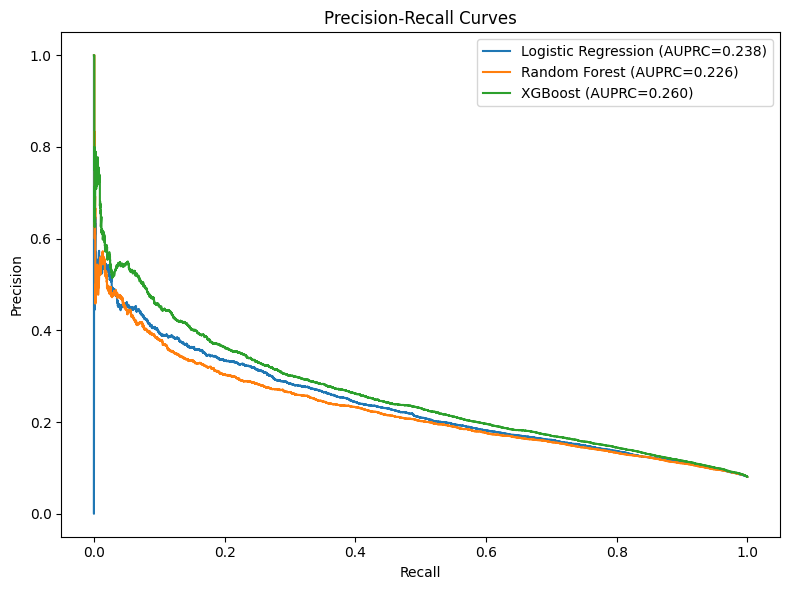

In [14]:
plt.figure(figsize=(8, 6))

for result in [log_result, rf_result, xgb_result]:
    precision, recall, _ = precision_recall_curve(y_test, result['y_proba'])
    plt.plot(recall, precision, label=f"{result['model']} (AUPRC={result['auprc']:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

cv_scores = cross_val_score(
    xgb_cv,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("CV AUROC scores:", cv_scores)
print("Mean AUROC:", cv_scores.mean())
print("Std AUROC:", cv_scores.std())

CV AUROC scores: [0.76041848 0.77107362 0.76236133 0.76869627 0.76125369]
Mean AUROC: 0.7647606756838592
Std AUROC: 0.0042954070232384374


In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
0.7627606986315757


In [17]:
best_params = search.best_params_

final_xgb = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

final_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [18]:
final_result = evaluate_model(
    "Final XGBoost",
    final_xgb,
    X_train,
    y_train,
    X_test,
    y_test
)

print("Final Model Performance:")
for k, v in final_result.items():
    if k not in ['y_proba', 'fitted_model']:
        print(f"{k}: {v}")

Final Model Performance:
model: Final XGBoost
auc: 0.7696600976013886
gini: 0.5393201952027773
ks: 0.40243138881862095
auprc: 0.2611496670985386
best_threshold: 0.6655318140983582
f1: 0.3204526840890477
precision: 0.25419324356248524
recall: 0.43343403826787513


##### The tuned XGBoost model shows improved performance after hyperparameter optimization, confirming that tuning tree depth, learning rate, and sampling parameters enhances generalization.

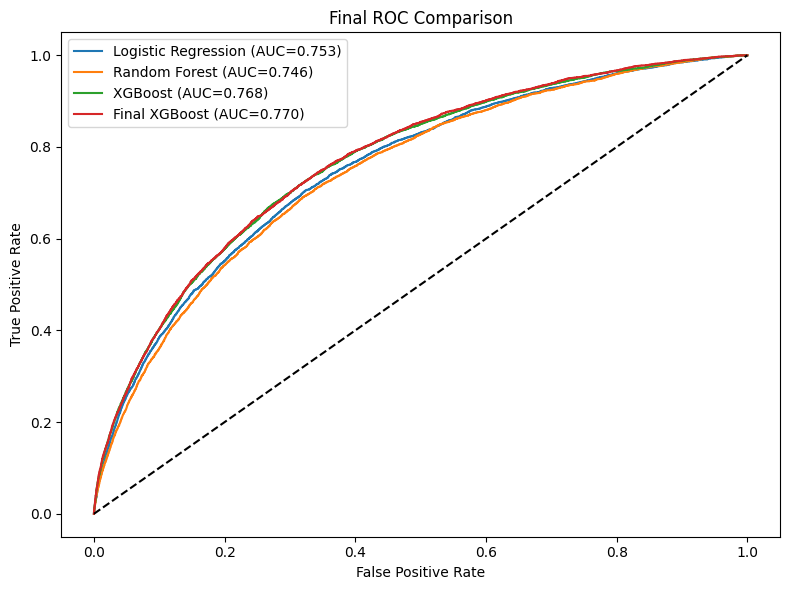

In [19]:
plt.figure(figsize=(8, 6))

for result in [log_result, rf_result, xgb_result, final_result]:
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    plt.plot(fpr, tpr, label=f"{result['model']} (AUC={result['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
final_table = pd.DataFrame([
    {k: v for k, v in log_result.items() if k not in ['y_proba', 'fitted_model']},
    {k: v for k, v in rf_result.items() if k not in ['y_proba', 'fitted_model']},
    {k: v for k, v in xgb_result.items() if k not in ['y_proba', 'fitted_model']},
    {k: v for k, v in final_result.items() if k not in ['y_proba', 'fitted_model']}
])

final_table = final_table[['model', 'auc', 'gini', 'ks', 'auprc', 'f1']]
final_table.sort_values('auc', ascending=False)

,model,auc,gini,ks,auprc,f1
3,Final XGBoost,0.769660,0.539320,0.402431,0.261150,0.320453
2,XGBoost,0.767845,0.535690,0.402841,0.259505,0.317881
0,Logistic Regression,0.753441,0.506881,0.381227,0.237592,0.305263
1,Random Forest,0.746369,0.492737,0.370535,0.226166,0.294799


In [21]:
import os
import joblib

os.makedirs('../models', exist_ok=True)

joblib.dump(final_xgb, '../models/best_model.pkl')

print("Final model saved successfully.")

Final model saved successfully.


In [22]:
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

['../models/feature_names.pkl']

In [23]:
summary = pd.DataFrame([{
    'Model': 'Final XGBoost',
    'AUROC': final_result['auc'],
    'Gini': final_result['gini'],
    'KS': final_result['ks'],
    'AUPRC': final_result['auprc'],
    'F1': final_result['f1']
}])

summary

,Model,AUROC,Gini,KS,AUPRC,F1
0,Final XGBoost,0.76966,0.53932,0.402431,0.26115,0.320453


##### Three models were evaluated: logistic regression, random forest, and XGBoost. Logistic regression provided a strong and interpretable baseline, while random forest improved performance by capturing non-linear relationships. XGBoost achieved the best performance with the highest AUROC (~0.77) and KS statistic (~0.40), indicating excellent separation between defaulters and non-defaulters. After hyperparameter tuning, XGBoost was selected as the final model due to its superior predictive performance. Explainability techniques such as SHAP will be applied in the next stage to ensure regulatory compliance.

### Customer Segmentation

In [24]:
cluster_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'CREDIT_INCOME_RATIO',
    'age',
    'EXT_SOURCE_MEAN',
    'num_bureau_records'
]

X_cluster = df[cluster_features].fillna(0)